# Evaluation of PUNet Precipitation Estimates

This notebook provides an interface to evaluate PERSIANN CCS  rainfall product against the SatRain benchmark dataset.

This notebook assumes that all PERSIANN PUnet files from 2021-01-01 to 2023-10-01 are available in a local folder. The files can be downloaded from [https://persiann.eng.uci.edu/CHRSdata/PUnet/PUnet1hourly/](https://persiann.eng.uci.edu/CHRSdata/PUnet/PUnet1hourly).

In [9]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
from typing import Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Helper functions

We define helper function to extract the temporal coverage from the CCS files and load the precipitation rates.

In [11]:
from datetime import datetime
PERSIANN_PATH = Path("/edata2/simon/satellite_data/persiann")

def filename_to_date(path: Path) -> np.datetime64:
    """
    Determine the start time of a PERSIANN PUNet file.

    Args:
        path: A Path object pointing to an PERSIANN PUNet file.

    Return:
        A numpy.datetime64 object representing the start time of the PERSIANN PUNet file.
    """
    path = Path(path)
    date_str = path.name.split(".")[0][-8:]
    date = datetime.strptime(date_str, "%y%m%d%H")
    return date

punet_files = sorted(list(PERSIANN_PATH.glob("PUnet1h*.bin.gz")))
punet_files = {filename_to_date(path): path for path in punet_files}

In [12]:
import gzip

def open_punet_file(path: Path) -> xr.Dataset:
    """
    Load binary PUNet results into xarray.Dataset.

    Args:
        path: A path object pointing to the PUNet file to open.

    Return:
        An xarray.Dataset containing the PUNet data.
    """
    bytes = gzip.open(path).read()
    dtype = "i2"
    data = np.frombuffer(bytes, dtype)
    n_pixels = data.size
    n_rows = int(np.sqrt(n_pixels // 3))
    shape = (n_rows, 3 * n_rows)
    data = data.reshape(shape)
    data = np.concatenate(
        [data[..., shape[1] // 2:], data[..., :shape[1] // 2]],
        axis=-1
    )
    data = (data / 100.0).astype(np.float32)
    data[data < 0] = np.nan
    
    lats = np.linspace(60.0, -60.0, shape[0] + 1)
    lats = 0.5 * (lats[1:] + lats[:-1])
    lons = np.linspace(-180, 180, shape[1] + 1)
    lons = 0.5 * (lons[1:] + lons[:-1])
    time = filename_to_date(path) 

    dataset = xr.Dataset({
        "time": (("time",), [time]),
        "latitude": (("latitude",), lats),
        "longitude": (("longitude",), lons),
        "surface_precip": (("time", "latitude", "longitude"), data[None]),
        "precip_flag": (("time", "latitude", "longitude"), (0.1 < data[None]).astype(np.float32)),
        "heavy_precip_flag": (("time", "latitude", "longitude"), (10.0 < data[None]).astype(np.float32)),
    })
    return dataset

## Retrieval callback function

The retrieval callback function ``retrieve_ccs`` loads the PERSIANN CCS data corresponding to a testing scene from the SatRain dataset. The ``input_data`` dataset contains the spatial coordinates and time of the overpass. The function loads all PERSIANN CCS data from the hours around the overpass and then interpolates the data in both space and time using nearest neighbor interpolation.

In [13]:
def retrieve_punet(input_data: xr.Dataset) -> xr.Dataset:
    """
    Retrieval callback function to load PUNet data corresponding to SATRAIN testing data.

    Args:
        input_data: An xarray.Dataset containing the retrieval input data.
    """
    time_min = np.nanmin(input_data.time.data)
    time_min = time_min.astype("datetime64[h]").astype("datetime64[s]")
    time_max = np.nanmax(input_data.time.data)
    time_max = time_max.astype("datetime64[h]").astype("datetime64[s]") + np.timedelta64(3600, "s")
    lons = input_data.longitude.data
    lats = input_data.latitude.data
    lon_min, lon_max = lons.min(), lons.max()
    lat_min, lat_max = lats.min(), lats.max()
    files = [
        punet_file for time, punet_file in punet_files.items()
        if time_min <= time and time <= time_max
    ]
    punet_data = xr.concat([open_punet_file(path) for path in files], "time")
    punet_data = punet_data.interp(
        latitude=input_data.latitude,
        longitude=input_data.longitude,
        time=input_data.time,
        method="nearest"
    )
    return punet_data

## Case study

To verify that the retrieval function returns the expected results, the ``evaulator`` provides a ``plot_retrieval_results`` function. As the name suggests, the function uses the ``retrieval_fn`` to obtain the retrieval results for a given scene and the plots them together with the reference precipitation. Here, we will use index 86 because this happens to be a scene with some interesting precipitation features that are reasonably well covered by MRMS measurements.

In [14]:
from satrain.target import TargetConfig
from satrain.evaluation import Evaluator

target_config = TargetConfig(min_rqi=0.5)
evaluator = Evaluator(
    domain="conus",
    base_sensor="gmi",
    geometry="gridded",
    retrieval_input=[],
    download=True,
    target_config=target_config,
)

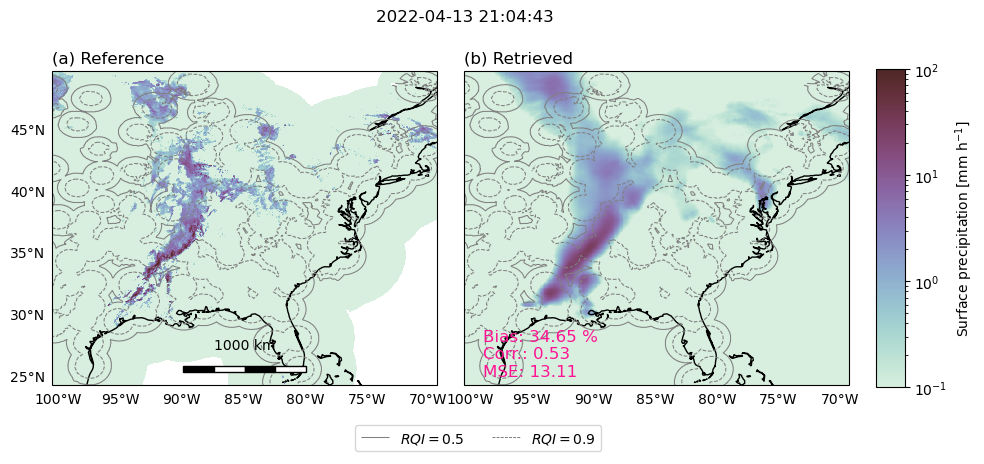

In [15]:
fig = evaluator.plot_retrieval_results(811, retrieve_punet, include_metrics=True)

## Running the evaluator

With the ``retrieval_fn`` callback function setup, the IMERG retrievals can be evaluated on the full evaluation dataset using the evaluator's ``evaluate`` function. This can be done using multiple processes to speed up the process.

In [ ]:
import logging
LOGGER = logging.getLogger("evaluation")
    
results = []
domains = ["austria", "conus", "korea"]
base_sensors = ["atms", "gmi"]

for sensor in base_sensors:
    for domain in domains:
        LOGGER.info("Running evaluation for domain '%s'.", domain)
        evaluator = Evaluator(
            domain=domain,
            base_sensor=sensor,
            geometry="gridded",
            retrieval_input=[],
            download=True,
            target_config=target_config,
        )
        evaluator.evaluate(
            retrieve_punet,
            n_processes=8
        )
        res = evaluator.get_results()
        results.append(res)
        res.to_netcdf(f"punet_{sensor}_{domain}.nc")

INFO     Running evaluation for domain 'austria'.

Output()

ERROR    Encountered an error when processing scene 413.                                                           
         concurrent.futures.process._RemoteTraceback:                                                              
         """                                                                                                       
         Traceback (most recent call last):                                                                        
           File "/home/simon/miniconda3/envs/ipwgml/lib/python3.10/site-packages/xarray/core/concat.py", line 253, 
         in concat                                                                                                 
             first_obj, objs = utils.peek_at(objs)                                                                 
           File "/home/simon/miniconda3/envs/ipwgml/lib/python3.10/site-packages/xarray/core/utils.py", line 205,  
         in peek_at                                                                                                
             peek = next(gen)                                                                                      
         StopIteration                                                                                             
                                                                                                                   
         During handling of the above exception, another exception occurred:                                       
                                                                                                                   
         Traceback (most recent call last):                                                                        
           File "/home/simon/miniconda3/envs/ipwgml/lib/python3.10/concurrent/futures/process.py", line 246, in    
         _process_worker                                                                                           
             r = call_item.fn(*call_item.args, **call_item.kwargs)                                                 
           File "/home/simon/src/satrain/src/satrain/evaluation.py", line 1239, in evaluate_scene_no_results       
             self.evaluate_scene(                                                                                  
           File "/home/simon/src/satrain/src/satrain/evaluation.py", line 1207, in evaluate_scene                  
             return evaluate_scene(                                                                                
           File "/home/simon/src/satrain/src/satrain/evaluation.py", line 581, in evaluate_scene                   
             results = process_scene_spatial(                                                                      
           File "/home/simon/src/satrain/src/satrain/evaluation.py", line 396, in process_scene_spatial            
             vars_retrieved = process(                                                                             
           File "/home/simon/src/satrain/src/satrain/evaluation.py", line 165, in process                          
             retrieved = retrieval_fn(input_data)                                                                  
           File "/tmp/ipykernel_241429/66749938.py", line 20, in retrieve_punet                                    
             punet_data = xr.concat([open_punet_file(path) for path in files], "time")                             
           File "/home/simon/miniconda3/envs/ipwgml/lib/python3.10/site-packages/xarray/core/concat.py", line 255, 
         in concat                                                                                                 
             raise ValueError("must supply at least one object to concatenate")                                    
         ValueError: must supply at least one object to concatenate                                                
         """                                            

INFO     Running evaluation for domain 'conus'.

Output()

...

Output()

ERROR    Encountered an error when processing scene 300.                                                           
         concurrent.futures.process._RemoteTraceback:                                                              
         """                                                                                                       
         Traceback (most recent call last):                                                                        
           File "/home/simon/miniconda3/envs/ipwgml/lib/python3.10/site-packages/xarray/core/concat.py", line 253, 
         in concat                                                                                                 
             first_obj, objs = utils.peek_at(objs)                                                                 
           File "/home/simon/miniconda3/envs/ipwgml/lib/python3.10/site-packages/xarray/core/utils.py", line 205,  
         in peek_at                                                                                                
             peek = next(gen)                                                                                      
         StopIteration                                                                                             
                                                                                                                   
         During handling of the above exception, another exception occurred:                                       
                                                                                                                   
         Traceback (most recent call last):                                                                        
           File "/home/simon/miniconda3/envs/ipwgml/lib/python3.10/concurrent/futures/process.py", line 246, in    
         _process_worker                                                                                           
             r = call_item.fn(*call_item.args, **call_item.kwargs)                                                 
           File "/home/simon/src/satrain/src/satrain/evaluation.py", line 1239, in evaluate_scene_no_results       
             self.evaluate_scene(                                                                                  
           File "/home/simon/src/satrain/src/satrain/evaluation.py", line 1207, in evaluate_scene                  
             return evaluate_scene(                                                                                
           File "/home/simon/src/satrain/src/satrain/evaluation.py", line 581, in evaluate_scene                   
             results = process_scene_spatial(                                                                      
           File "/home/simon/src/satrain/src/satrain/evaluation.py", line 396, in process_scene_spatial            
             vars_retrieved = process(                                                                             
           File "/home/simon/src/satrain/src/satrain/evaluation.py", line 165, in process                          
             retrieved = retrieval_fn(input_data)                                                                  
           File "/tmp/ipykernel_241429/66749938.py", line 20, in retrieve_punet                                    
             punet_data = xr.concat([open_punet_file(path) for path in files], "time")                             
           File "/home/simon/miniconda3/envs/ipwgml/lib/python3.10/site-packages/xarray/core/concat.py", line 255, 
         in concat                                                                                                 
             raise ValueError("must supply at least one object to concatenate")                                    
         ValueError: must supply at least one object to concatenate                                                
         """                                            

ERROR    Encountered an error when processing scene 301.                                                           
         concurrent.futures.process._RemoteTraceback:                                                              
         """                                                                                                       
         Traceback (most recent call last):                                                                        
           File "/home/simon/miniconda3/envs/ipwgml/lib/python3.10/site-packages/xarray/core/concat.py", line 253, 
         in concat                                                                                                 
             first_obj, objs = utils.peek_at(objs)                                                                 
           File "/home/simon/miniconda3/envs/ipwgml/lib/python3.10/site-packages/xarray/core/utils.py", line 205,  
         in peek_at                                                                                                
             peek = next(gen)                                                                                      
         StopIteration                                                                                             
                                                                                                                   
         During handling of the above exception, another exception occurred:                                       
                                                                                                                   
         Traceback (most recent call last):                                                                        
           File "/home/simon/miniconda3/envs/ipwgml/lib/python3.10/concurrent/futures/process.py", line 246, in    
         _process_worker                                                                                           
             r = call_item.fn(*call_item.args, **call_item.kwargs)                                                 
           File "/home/simon/src/satrain/src/satrain/evaluation.py", line 1239, in evaluate_scene_no_results       
             self.evaluate_scene(                                                                                  
           File "/home/simon/src/satrain/src/satrain/evaluation.py", line 1207, in evaluate_scene                  
             return evaluate_scene(                                                                                
           File "/home/simon/src/satrain/src/satrain/evaluation.py", line 581, in evaluate_scene                   
             results = process_scene_spatial(                                                                      
           File "/home/simon/src/satrain/src/satrain/evaluation.py", line 396, in process_scene_spatial            
             vars_retrieved = process(                                                                             
           File "/home/simon/src/satrain/src/satrain/evaluation.py", line 165, in process                          
             retrieved = retrieval_fn(input_data)                                                                  
           File "/tmp/ipykernel_241429/66749938.py", line 20, in retrieve_punet                                    
             punet_data = xr.concat([open_punet_file(path) for path in files], "time")                             
           File "/home/simon/miniconda3/envs/ipwgml/lib/python3.10/site-packages/xarray/core/concat.py", line 255, 
         in concat                                                                                                 
             raise ValueError("must supply at least one object to concatenate")                                    
         ValueError: must supply at least one object to concatenate                                                
         """                                            

INFO     Running evaluation for domain 'conus'.

Output()